# TCC Parte 2 - Treinamento dos modelos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os
import pickle
from datetime import datetime

from sklearn.model_selection import BaseCrossValidator
import tensorflow as tf
from tensorflow.keras.layers import LSTM, Input, Dense, GRU, SimpleRNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.ensemble import RandomForestClassifier
import random

RANDOM_STATE = 21

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

from modules.dataframe_helpers import preprocess_data_test, check_time_index_overlap
from modules.financial_helpers import *
from modules.chart_helpers import *

2025-03-22 16:24:22.241416: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
stocks_df = pd.read_csv("data/stocks_df.csv")
stocks_df['Date'] = pd.to_datetime(stocks_df['Date'], format='%Y-%m-%d')
stocks_df.set_index('Date', inplace=True)


exploration_df = pd.read_csv("data/exploration_df.csv")
exploration_df['Date'] = pd.to_datetime(exploration_df['Date'], format='%Y-%m-%d')
exploration_df.set_index('Date', inplace=True)

In [3]:
stocks_df.head()

,Price_abev3,Price_bbdc3,Price_itub3,Price_itsa3,Price_wege3
Date,,,,,
2007-10-04,2.99,6.00,7.44,3.48,2.40
2007-10-05,3.06,6.30,7.86,3.52,2.43
2007-10-08,3.06,6.31,7.95,3.43,2.45
2007-10-09,3.08,6.38,8.30,3.44,2.44
2007-10-10,3.04,6.35,8.15,3.43,2.43


## Definindo o Sliding Window CV

Essa classe irá dividir os dados para treino/teste de modo a evitar overlap entre os dias de teste, avançando do começo até o fim. Isso significa que os primeiros n dias escolhidos para treino serão "perdidos" no sentido de que eles não farão parte do portfólio hipotético formado pelos modelos

In [4]:
class SlidingWindowExclusiveTestCV(BaseCrossValidator):
    def __init__(self, train_size: int, val_size: int):
        self.train_size = train_size
        self.val_size = val_size

    def get_n_splits(self, X=None, y=None, groups=None):
        """
        On a CV splitter (not an estimator), returns the number of elements one would get if iterating through 
        the return value of split given the same parameters. Takes the same parameters as split.
        """
        n_samples = len(X)
        count = 0
        for _ in range(0, n_samples - self.train_size - self.val_size + 1, self.val_size):
            count += 1
        return count

    def split(self, X=None, y=None, groups=None):
        """
        On a CV splitter (not an estimator), this method accepts parameters (X, y, groups), where all may be optional, 
        and returns an iterator over (train_idx, test_idx) pairs. Each of {train,test}_idx is a 1d integer array, 
        with values from 0 from X.shape[0] - 1 of any length, such that no values appear in both some train_idx and 
        its corresponding test_idx.
        """
        n_samples = len(X)
        for start in range(0, n_samples - self.train_size - self.val_size + 1, self.val_size):
            train_indices = np.arange(start, start + self.train_size)
            test_indices = np.arange(start + self.train_size, start + self.train_size + self.val_size)
            yield train_indices, test_indices

### Visualizando o Cross Validator em ação

No overlap found; all time indices are mutually exclusive.


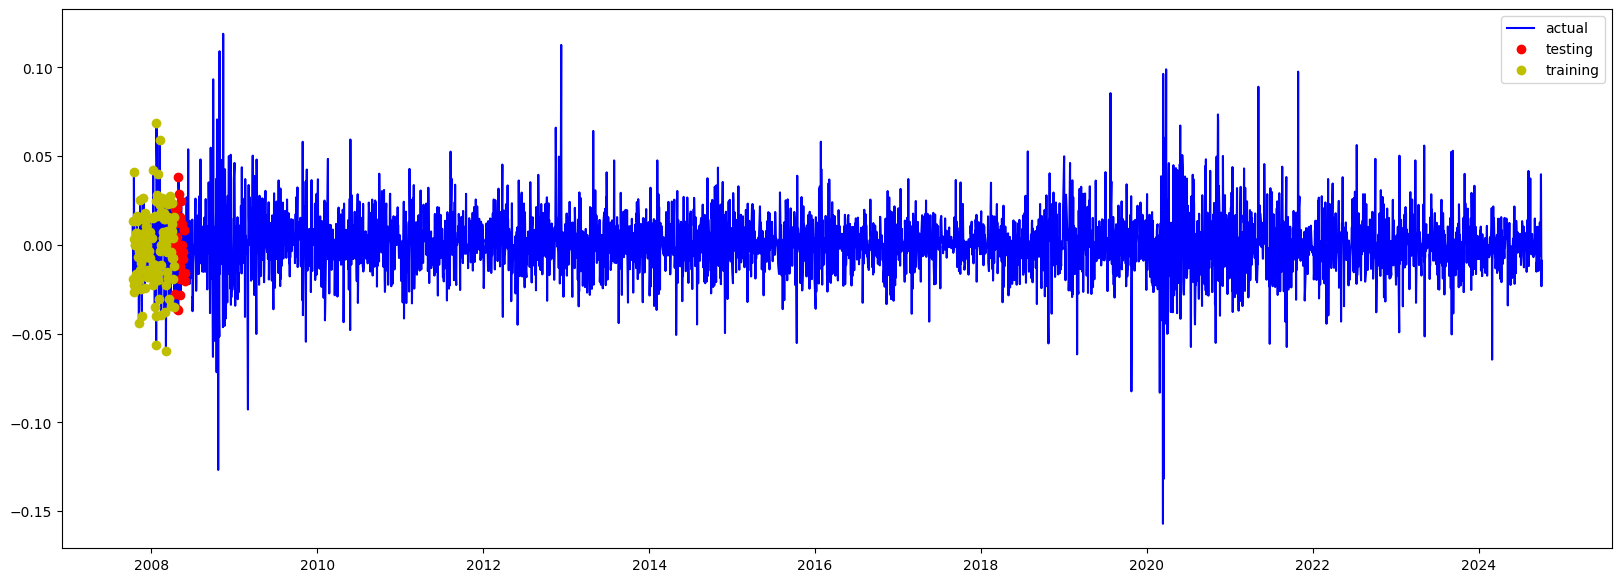

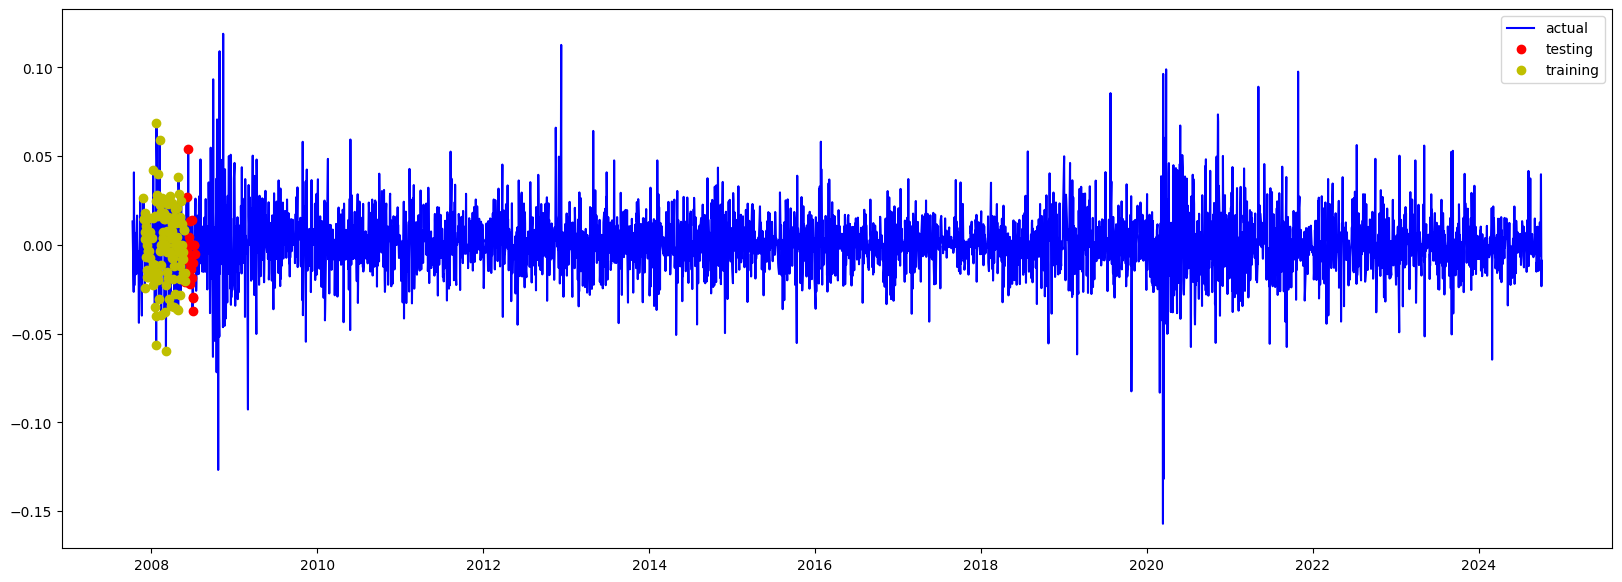

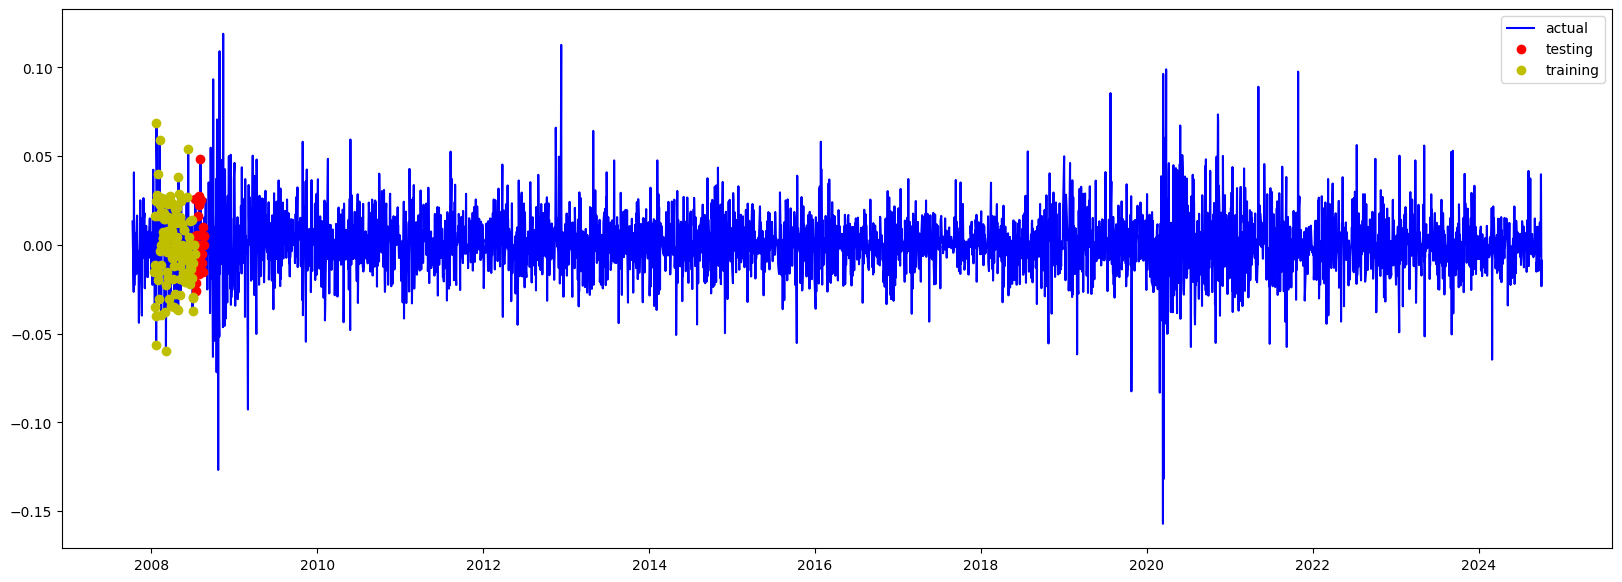

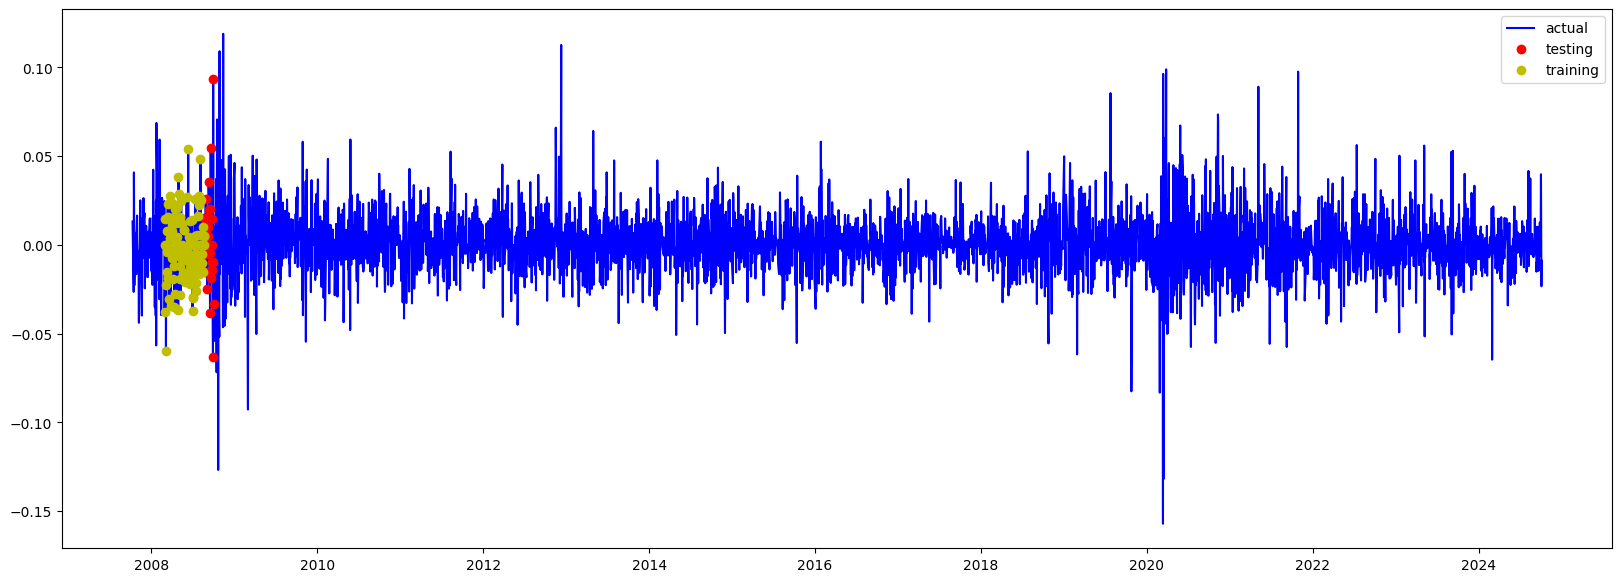

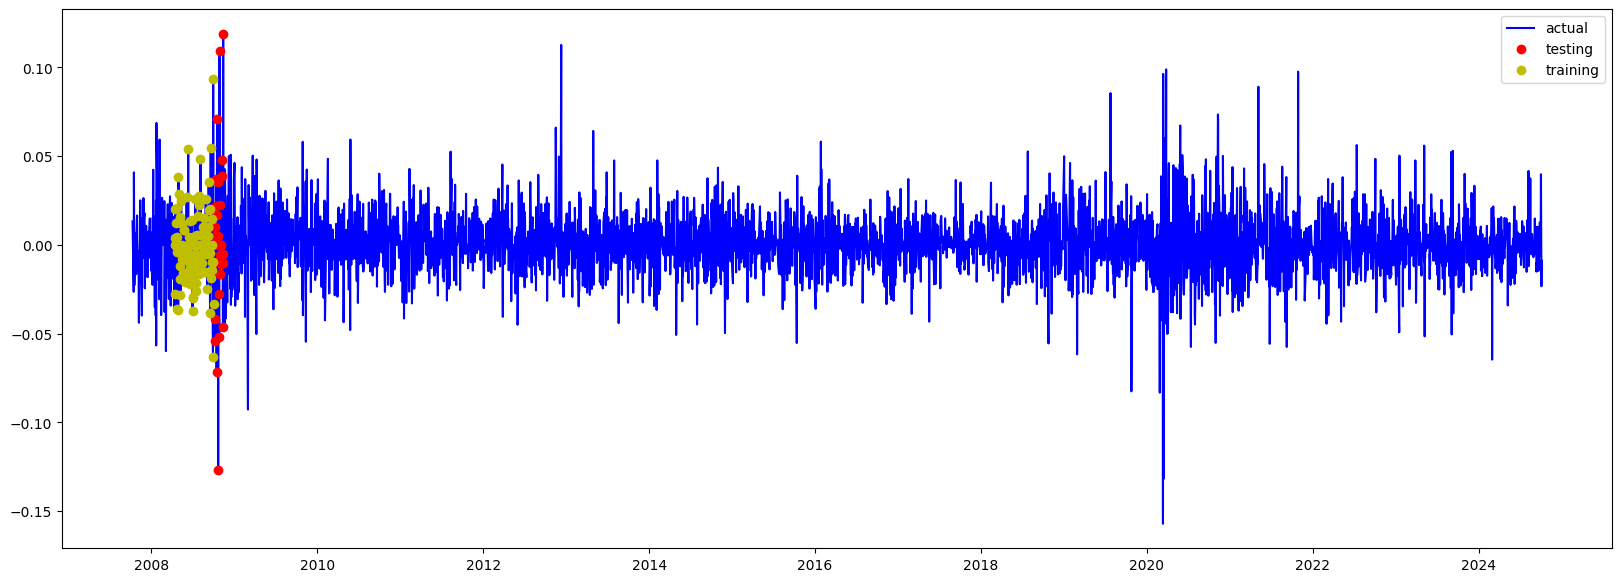

In [5]:
cv = SlidingWindowExclusiveTestCV(120, 30)

count = 0

tests = []
trains = []

df = preprocess_data_test(stocks_df, "abev3")

for train_index, test_index in cv.split(df["Return_abev3"]):
    X_train, X_test = df["Return_abev3"].iloc[train_index], df["Return_abev3"].iloc[test_index]
    tests.append(X_test)
    trains.append(X_train)

    if count in range(5):
        plt.figure(figsize=(20, 7))
        plt.plot(df.index, df["Return_abev3"], 'b-', label = 'actual')
        plt.plot(X_test.index, X_test, 'ro', label = 'testing')
        plt.plot(X_train.index, X_train, 'yo', label = 'training')
        plt.legend()
        plt.plot()

    count += 1

assert check_time_index_overlap(tests) == False
assert type(tests[0]) == pd.Series
assert trains[0].index[0] == df["Return_abev3"].index[0]

In [6]:
tests[0].index[-1], tests[1].index[0], tests[1].index[-1], tests[2].index[0], tests[2].index[-1], tests[3].index[0]

(Timestamp('2008-05-28 00:00:00'),
 Timestamp('2008-05-29 00:00:00'),
 Timestamp('2008-07-10 00:00:00'),
 Timestamp('2008-07-11 00:00:00'),
 Timestamp('2008-08-21 00:00:00'),
 Timestamp('2008-08-22 00:00:00'))

In [7]:
trains[1].index[-1], tests[1].index[0], trains[2].index[-1], tests[2].index[0], trains[3].index[-1], tests[3].index[0]

(Timestamp('2008-05-28 00:00:00'),
 Timestamp('2008-05-29 00:00:00'),
 Timestamp('2008-07-10 00:00:00'),
 Timestamp('2008-07-11 00:00:00'),
 Timestamp('2008-08-21 00:00:00'),
 Timestamp('2008-08-22 00:00:00'))

Treino e teste não aparentam estar vazando um no outro

# LSTM

In [8]:
TRAINING_EPOCHS = 250
PATIENCE = int(TRAINING_EPOCHS * 0.1)

BATCH_SIZE = 64
NUM_EXPERIMENTS = 30

TRAIN_SIZE = 120
VAL_SIZE = 30

NN_HIDDEN_UNITS = 8

In [9]:
def define_lstm(data_shape, num_units):
    lstm = Sequential()

    lstm.add(Input(shape=data_shape))
    lstm.add(LSTM(num_units))
    lstm.add(Dense(1, activation="sigmoid"))

    lstm.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

    return lstm

In [10]:
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=PATIENCE,
    restore_best_weights=True,
	mode='max'
)

In [11]:
def run_lstm_experiment(train_size: int, val_size: int, stock: str, num_units: int, random_seed: int):
    print(stock)
    np.random.seed(random_seed)
    random.seed(random_seed)
    tf.random.set_seed(random_seed)

    model = define_lstm((5, 1), num_units) # 5 time steps, 1 feature (return)
    cv_splitter = SlidingWindowExclusiveTestCV(train_size, val_size)

    tests = []
    results = {}
    ground_y = []

    start_time = datetime.now()
    for train_index, test_index in cv_splitter.split(stocks_df):
        preprocessed_train_data = preprocess_data(stocks_df, stock, train_index[0], train_index[-1])
        preprocessed_test_data = preprocess_data(stocks_df, stock, test_index[0], test_index[-1])
        
        train_features = preprocessed_train_data.drop([f"{stock}_y"], axis=1)
        train_targets = preprocessed_train_data[f"{stock}_y"]

        test_features = preprocessed_test_data.drop([f"{stock}_y"], axis=1)
        test_targets = preprocessed_test_data[f"{stock}_y"]

        # just so I can rename variables
        X_train, X_test = train_features, test_features
        y_train, y_test = train_targets, test_targets

        scaler = MinMaxScaler(feature_range=(-1, 1))
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        model.fit(
            X_train, y_train,
            epochs = TRAINING_EPOCHS,
            batch_size=BATCH_SIZE,
            validation_split=0.2,
            callbacks=[early_stopping],
            shuffle=False,
            verbose=False,
        )

        y_hat = model.predict(X_test, verbose=False)

        # turn probas into labels
        y_hat = np.array(y_hat)
        for i in range(len(y_hat)):
            if y_hat[i] > 0.5:
                y_hat[i] = True
            else:
                y_hat[i] = False

        # append preds and grounds into array
        for i, y_pred in enumerate(y_hat):
            tests.append({y_test.index[i]: y_pred.astype(int)[0]})
        
        for i, y_true in enumerate(y_hat):
            ground_y.append({y_test.index[i]: y_test.iloc[i].astype(int)})
            
    end_time = datetime.now()
    
    # extract values from result data structure
    preds_to_compute = [list(i.values())[0] for i in tests]
    grounds_to_compute = [list(i.values())[0] for i in ground_y]
    
    results = {
        "preds": preds_to_compute,
        "ground": grounds_to_compute,
        "accuracy": accuracy_score(grounds_to_compute, preds_to_compute),
        "f1": f1_score(grounds_to_compute, preds_to_compute),
        "precision": precision_score(grounds_to_compute, preds_to_compute, zero_division=0),
        "recall": recall_score(grounds_to_compute, preds_to_compute),
        "dataset_fit_predict_time": (end_time - start_time).total_seconds()
    }

    # all_accs.append(np.array(accs).mean())
    np.random.seed(RANDOM_STATE)
    random.seed(RANDOM_STATE)
    tf.random.set_seed(RANDOM_STATE)

    return results, tests

In [12]:
results_lstm_1_path = "./results/lstm_01"

if not os.path.isfile(results_lstm_1_path):
    results_lstm_1 = []

    for i in range(NUM_EXPERIMENTS):
        print(f"EXECUTION NUMBER {i+1}")
        abev3_lstm_res, abev3_preds = run_lstm_experiment( 
            TRAIN_SIZE, 
            VAL_SIZE, 
            "abev3", 
            NN_HIDDEN_UNITS,
            i
        )

        bbdc3_lstm_res, bbdc3_preds = run_lstm_experiment(
            TRAIN_SIZE, 
            VAL_SIZE, 
            "bbdc3", 
            NN_HIDDEN_UNITS,
            i
        )

        itsa3_lstm_res, itsa3_preds = run_lstm_experiment(
            TRAIN_SIZE, 
            VAL_SIZE, 
            "itsa3", 
            NN_HIDDEN_UNITS,
            i
        )

        itub3_lstm_res, itub3_preds = run_lstm_experiment(
            TRAIN_SIZE, 
            VAL_SIZE, 
            "itub3", 
            NN_HIDDEN_UNITS,
            i
        )

        wege3_lstm_res, wege3_preds = run_lstm_experiment(
            TRAIN_SIZE, 
            VAL_SIZE, 
            "wege3", 
            NN_HIDDEN_UNITS,
            i
        )

        results_lstm_1.append({
            "abev3": (abev3_lstm_res, abev3_preds),
            "bbdc3": (bbdc3_lstm_res, bbdc3_preds),
            "itsa3": (itsa3_lstm_res, itsa3_preds),
            "itub3": (itub3_lstm_res, itub3_preds),
            "wege3": (wege3_lstm_res, wege3_preds)
        })

    !mkdir "./results/"
    with open(results_lstm_1_path, "wb") as f:
        pickle.dump(results_lstm_1, f)

else:
    with open(results_lstm_1_path, "rb") as f:
        results_lstm_1 = pickle.load(f)

In [13]:
return_cols = [col for col in exploration_df.columns.tolist() if "Return" in col and "lag" not in col]
return_cols

['Return_abev3',
 'Return_bbdc3',
 'Return_itub3',
 'Return_itsa3',
 'Return_wege3']

In [14]:
start_date1 = list(results_lstm_1[0]["abev3"][1][0].keys())[0]
end_date1 = list(results_lstm_1[0]["abev3"][1][-1].keys())[0]

In [15]:
daily_returns = exploration_df[return_cols].loc[start_date1 : end_date1]
daily_returns

,Return_abev3,Return_bbdc3,Return_itub3,Return_itsa3,Return_wege3
Date,,,,,
2008-04-07,-0.019231,0.009728,-0.002924,0.000000,0.000000
2008-04-08,0.003922,0.013487,-0.004399,0.009174,0.000000
2008-04-09,-0.011719,-0.020913,0.002946,0.003030,-0.009132
2008-04-10,0.015810,0.017476,-0.011747,-0.021148,-0.013825
2008-04-11,-0.035019,-0.019084,-0.013373,0.000000,-0.023364
...,...,...,...,...,...
2024-09-06,0.001542,-0.014604,-0.008576,0.001792,-0.020586
2024-09-09,0.009238,0.002823,0.002162,0.000894,-0.008142
2024-09-10,0.009916,0.002815,0.001850,0.004468,0.008400


In [16]:
daily_returns.to_csv("data/buy_and_hold_df.csv")

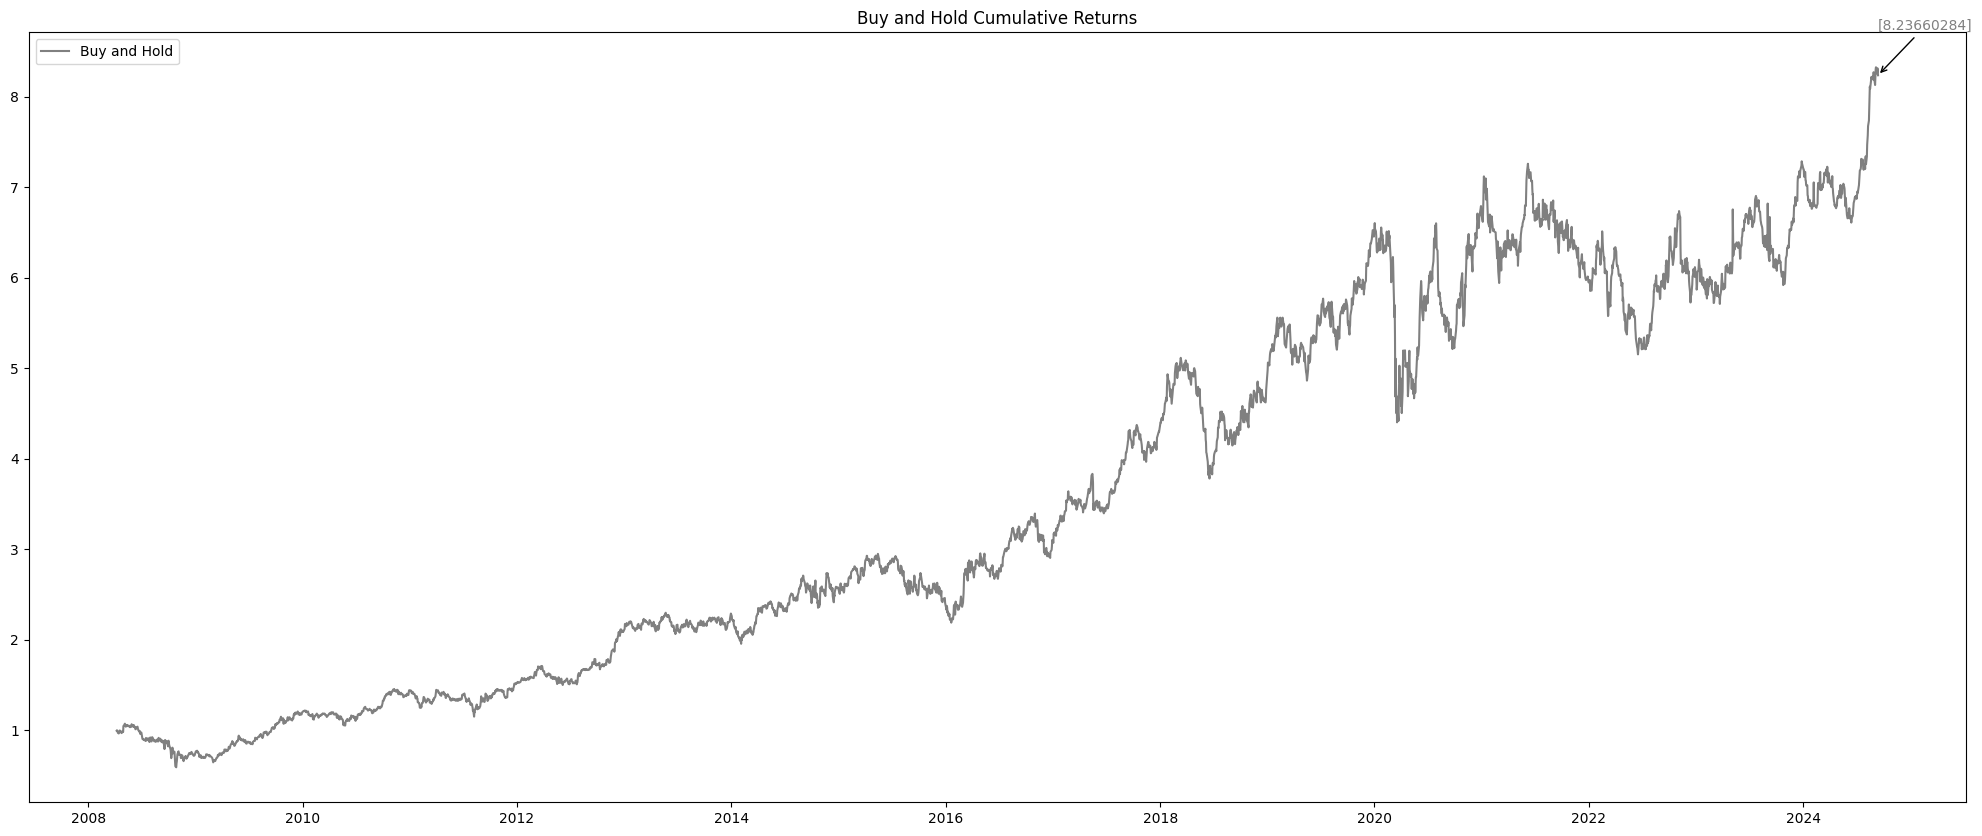

In [17]:
buy_and_hold_cuml_returns, portfolio_returns = compute_buyandhold_cumulative_returns(daily_returns)
plot_many_returns_series([buy_and_hold_cuml_returns], ["Buy and Hold"], buy_and_hold_cuml_returns.index, [model_colors["B&H"]], title="Buy and Hold Cumulative Returns")

In [18]:
buy_and_hold_sharpe = compute_sharpe_ratio(portfolio_returns)
buy_and_hold_sharpe

0.01675759317690581

In [19]:
abev3_test = results_lstm_1[0]["abev3"][1]
bbdc3_test = results_lstm_1[0]["bbdc3"][1]
itsa3_test = results_lstm_1[0]["itsa3"][1]
itub3_test = results_lstm_1[0]["itub3"][1]
wege3_test = results_lstm_1[0]["wege3"][1]

In [20]:
inclusion_mask = pd.DataFrame({
    'Return_abev3': pd.Series([list(val.values())[0] for val in abev3_test], index=[list(val.keys())[0] for val in abev3_test]),
    'Return_bbdc3': pd.Series([list(val.values())[0] for val in bbdc3_test], index=[list(val.keys())[0] for val in bbdc3_test]),
    'Return_itsa3': pd.Series([list(val.values())[0] for val in itsa3_test], index=[list(val.keys())[0] for val in itsa3_test]),
    'Return_itub3': pd.Series([list(val.values())[0] for val in itub3_test], index=[list(val.keys())[0] for val in itub3_test]),
    'Return_wege3': pd.Series([list(val.values())[0] for val in wege3_test], index=[list(val.keys())[0] for val in wege3_test]),
})

inclusion_mask.shift(1).head()

,Return_abev3,Return_bbdc3,Return_itsa3,Return_itub3,Return_wege3
2008-04-07,NaN,NaN,NaN,NaN,NaN
2008-04-08,0.0,0.0,1.0,1.0,1.0
2008-04-09,0.0,0.0,0.0,0.0,1.0
2008-04-10,0.0,0.0,0.0,0.0,1.0
2008-04-11,0.0,0.0,0.0,0.0,1.0


In [21]:
best_results_lstm_01, cuml_perf_lstm_01, max_sharpe_lstm_01, best_exp_idx_lstm = find_best_experiment(results_lstm_1, daily_returns)

Selected exp number 25


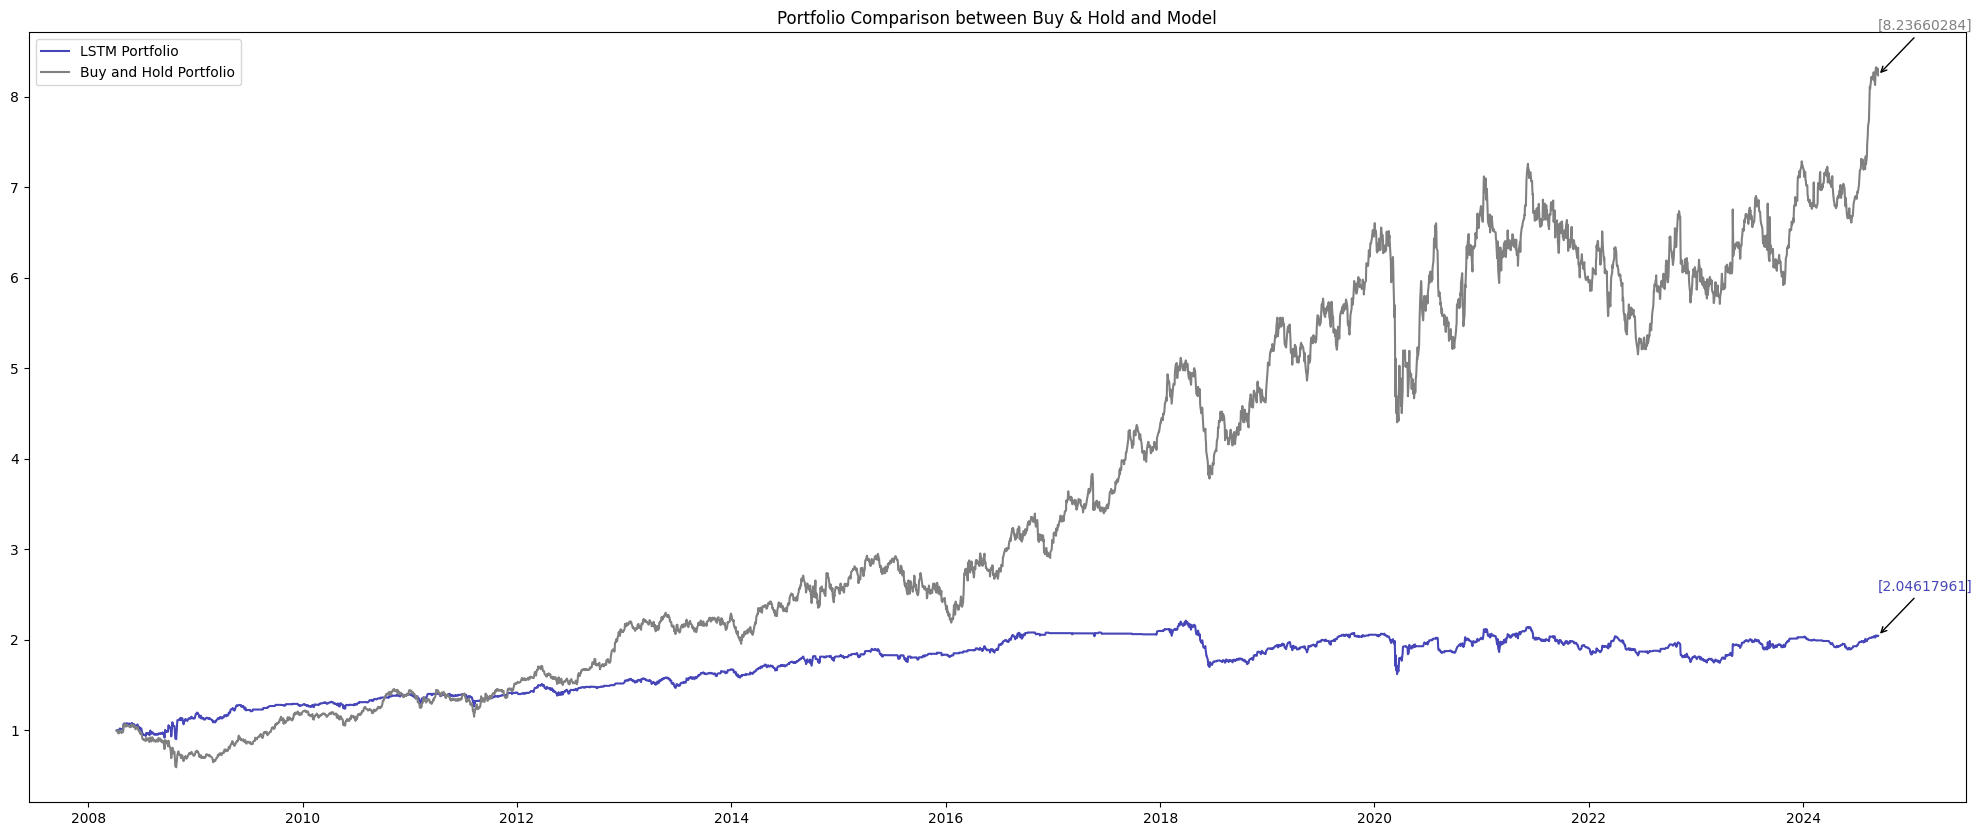

In [22]:
buy_and_hold1, _ = compute_buyandhold_cumulative_returns(exploration_df[return_cols].loc[start_date1 : end_date1])

plot_many_returns_series(
    [cuml_perf_lstm_01, buy_and_hold1],
    ["LSTM Portfolio", "Buy and Hold Portfolio"], 
    daily_returns.index,
    colors=[model_colors["LSTM"], model_colors["B&H"]]
)

In [23]:
max_sharpe_lstm_01, buy_and_hold_sharpe

(-0.02219927972908448, 0.01675759317690581)

# GRU

In [24]:
def define_gru(data_shape, num_units):
    gru = Sequential()

    gru.add(Input(shape=data_shape))
    gru.add(GRU(num_units))
    gru.add(Dense(1, activation="sigmoid"))

    gru.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

    return gru

In [25]:
def run_gru_experiment(train_size: int, val_size: int, stock: str, num_units: int, random_seed: int):
    print(stock)
    np.random.seed(random_seed)
    random.seed(random_seed)
    tf.random.set_seed(random_seed)

    model = define_gru((5, 1), num_units) # 5 time steps, 1 feature (return)
    cv_splitter = SlidingWindowExclusiveTestCV(train_size, val_size)

    tests = []
    results = {}
    ground_y = []

    start_time = datetime.now()
    for train_index, test_index in cv_splitter.split(stocks_df):
        preprocessed_train_data = preprocess_data(stocks_df, stock, train_index[0], train_index[-1])
        preprocessed_test_data = preprocess_data(stocks_df, stock, test_index[0], test_index[-1])
        
        train_features = preprocessed_train_data.drop([f"{stock}_y"], axis=1)
        train_targets = preprocessed_train_data[f"{stock}_y"]

        test_features = preprocessed_test_data.drop([f"{stock}_y"], axis=1)
        test_targets = preprocessed_test_data[f"{stock}_y"]

        # just so I can rename variables
        X_train, X_test = train_features, test_features
        y_train, y_test = train_targets, test_targets

        scaler = MinMaxScaler(feature_range=(-1, 1))
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        model.fit(
            X_train, y_train,
            epochs = TRAINING_EPOCHS,
            batch_size=BATCH_SIZE,
            validation_split=0.2,
            callbacks=[early_stopping],
            shuffle=False,
            verbose=False,
        )

        y_hat = model.predict(X_test, verbose=False)

        # turn probas into labels
        y_hat = np.array(y_hat)
        for i in range(len(y_hat)):
            if y_hat[i] > 0.5:
                y_hat[i] = True
            else:
                y_hat[i] = False

        # append preds and grounds into array
        for i, y_pred in enumerate(y_hat):
            tests.append({y_test.index[i]: y_pred.astype(int)[0]})
        
        for i, y_true in enumerate(y_hat):
            ground_y.append({y_test.index[i]: y_test.iloc[i].astype(int)})
            
    end_time = datetime.now()
    
    # extract values from result data structure
    preds_to_compute = [list(i.values())[0] for i in tests]
    grounds_to_compute = [list(i.values())[0] for i in ground_y]
    
    results = {
        "preds": preds_to_compute,
        "ground": grounds_to_compute,
        "accuracy": accuracy_score(grounds_to_compute, preds_to_compute),
        "f1": f1_score(grounds_to_compute, preds_to_compute),
        "precision": precision_score(grounds_to_compute, preds_to_compute, zero_division=0),
        "recall": recall_score(grounds_to_compute, preds_to_compute),
        "dataset_fit_predict_time": (end_time - start_time).total_seconds()
    }

    # all_accs.append(np.array(accs).mean())
    np.random.seed(RANDOM_STATE)
    random.seed(RANDOM_STATE)
    tf.random.set_seed(RANDOM_STATE)

    return results, tests

In [26]:
results_gru_1_path = "./results/gru_01"

if not os.path.isfile(results_gru_1_path):
    results_gru_1 = []

    for i in range(NUM_EXPERIMENTS):
        print(f"Experiment {i+1}")
        abev3_gru_res, abev3_gru_preds = run_gru_experiment(
            TRAIN_SIZE, 
            VAL_SIZE, 
            "abev3",
            NN_HIDDEN_UNITS,
            i
        )

        bbdc3_gru_res, bbdc3_gru_preds = run_gru_experiment(
            TRAIN_SIZE, 
            VAL_SIZE, 
            "bbdc3", 
            NN_HIDDEN_UNITS,
            i
        )

        itsa3_gru_res, itsa3_gru_preds = run_gru_experiment(
            TRAIN_SIZE, 
            VAL_SIZE, 
            "itsa3", 
            NN_HIDDEN_UNITS,
            i
        )

        itub3_gru_res, itub3_gru_preds = run_gru_experiment(
            TRAIN_SIZE, 
            VAL_SIZE, 
            "itub3", 
            NN_HIDDEN_UNITS,
            i
        )

        wege3_gru_res, wege3_gru_preds = run_gru_experiment(
            TRAIN_SIZE, 
            VAL_SIZE, 
            "wege3", 
            NN_HIDDEN_UNITS,
            i
        )

        results_gru_1.append({
            "abev3": (abev3_gru_res, abev3_gru_preds),
            "bbdc3": (bbdc3_gru_res, bbdc3_gru_preds),
            "itsa3": (itsa3_gru_res, itsa3_gru_preds),
            "itub3": (itub3_gru_res, itub3_gru_preds),
            "wege3": (wege3_gru_res, wege3_gru_preds)
        })

    !mkdir "./results/"
    with open(results_gru_1_path, "wb") as f:
        pickle.dump(results_gru_1, f)

else:
    with open(results_gru_1_path, "rb") as f:
        results_gru_1 = pickle.load(f)

In [27]:
best_results_gru_1, cuml_perf_gru_1, max_sharpe_gru_1, best_exp_idx_gru = find_best_experiment(results_gru_1, daily_returns)
# plot_cumulative_returns_line_chart(cuml_perf_gru_1)

Selected exp number 25


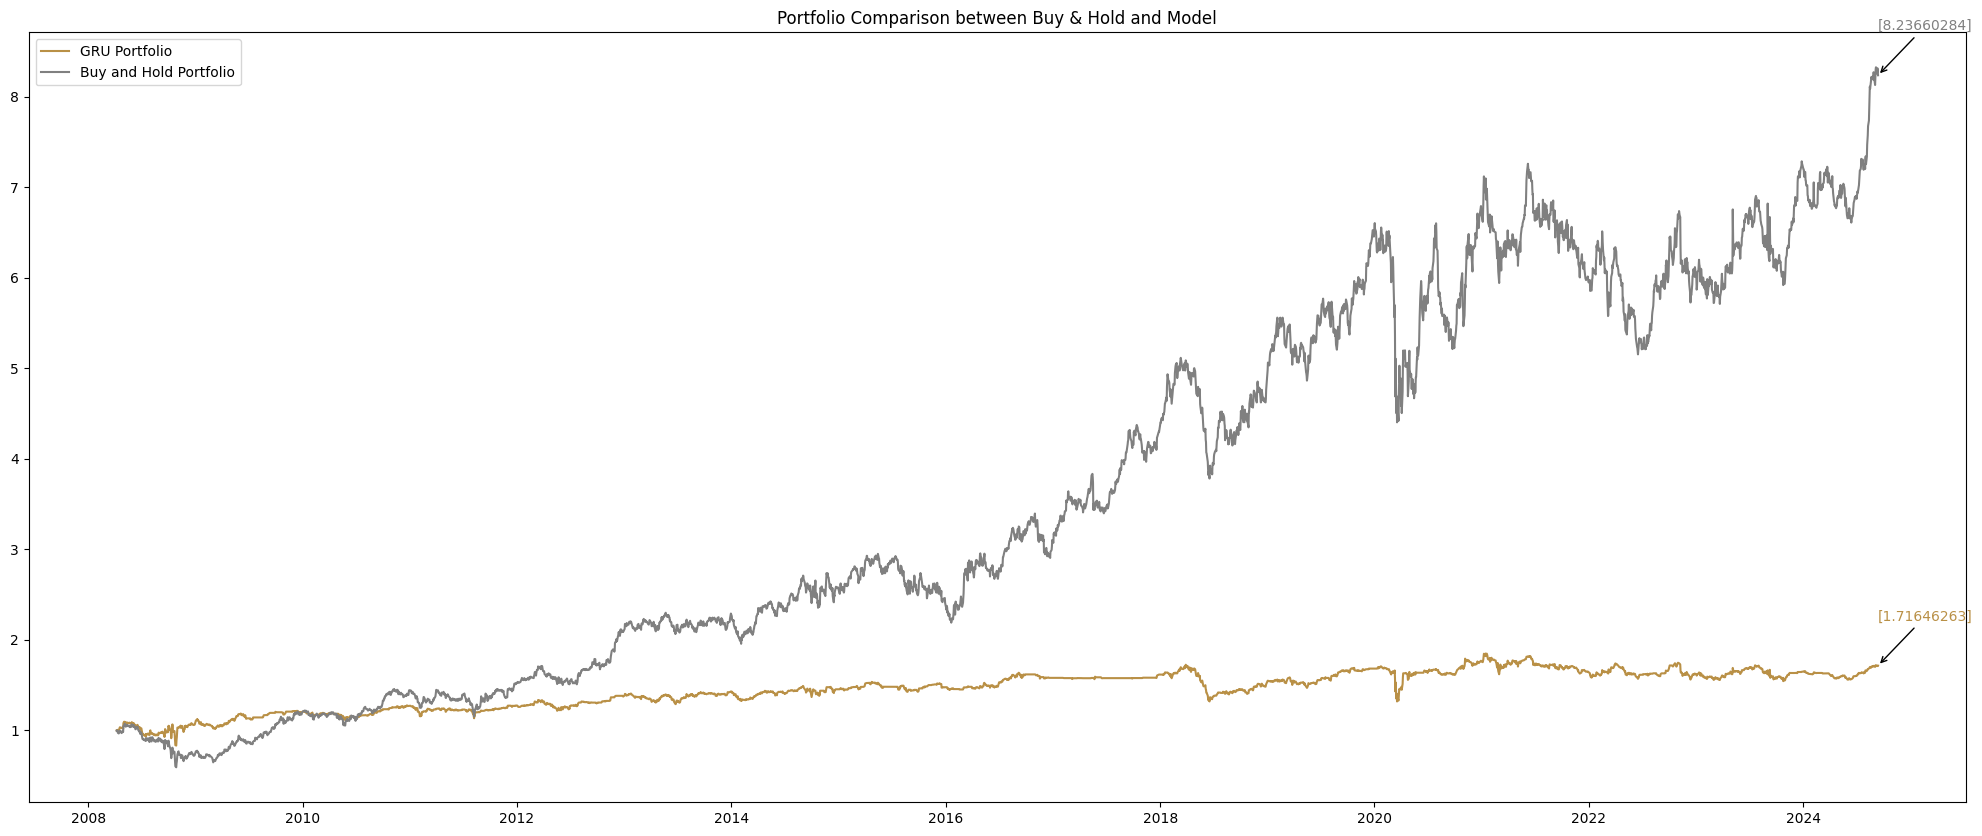

In [28]:
plot_many_returns_series(
    [cuml_perf_gru_1, buy_and_hold1],
    ["GRU Portfolio", "Buy and Hold Portfolio"], 
    daily_returns.index,
    colors=[model_colors["GRU"], model_colors["B&H"]]
)

In [29]:
max_sharpe_gru_1, buy_and_hold_sharpe

(-0.02574279096131124, 0.01675759317690581)

# RNN Simples

In [30]:
def define_rnn(data_shape, num_units):
    rnn = Sequential()

    rnn.add(Input(shape=data_shape))
    rnn.add(SimpleRNN(num_units))
    rnn.add(Dense(1, activation="sigmoid"))

    rnn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

    return rnn

In [31]:
def run_rnn_experiment(train_size: int, val_size: int, stock: str, num_units: int, random_seed: int):
    print(stock)
    np.random.seed(random_seed)
    random.seed(random_seed)
    tf.random.set_seed(random_seed)

    model = define_rnn((5, 1), num_units) # 5 time steps, 1 feature (return)
    cv_splitter = SlidingWindowExclusiveTestCV(train_size, val_size)

    tests = []
    results = {}
    ground_y = []

    start_time = datetime.now()
    for train_index, test_index in cv_splitter.split(stocks_df):
        preprocessed_train_data = preprocess_data(stocks_df, stock, train_index[0], train_index[-1])
        preprocessed_test_data = preprocess_data(stocks_df, stock, test_index[0], test_index[-1])
        
        train_features = preprocessed_train_data.drop([f"{stock}_y"], axis=1)
        train_targets = preprocessed_train_data[f"{stock}_y"]

        test_features = preprocessed_test_data.drop([f"{stock}_y"], axis=1)
        test_targets = preprocessed_test_data[f"{stock}_y"]

        # just so I can rename variables
        X_train, X_test = train_features, test_features
        y_train, y_test = train_targets, test_targets

        scaler = MinMaxScaler(feature_range=(-1, 1))
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        model.fit(
            X_train, y_train,
            epochs = TRAINING_EPOCHS,
            batch_size=BATCH_SIZE,
            validation_split=0.2,
            callbacks=[early_stopping],
            shuffle=False,
            verbose=False,
        )

        y_hat = model.predict(X_test, verbose=False)

        # turn probas into labels
        y_hat = np.array(y_hat)
        for i in range(len(y_hat)):
            if y_hat[i] > 0.5:
                y_hat[i] = True
            else:
                y_hat[i] = False

        # append preds and grounds into array
        for i, y_pred in enumerate(y_hat):
            tests.append({y_test.index[i]: y_pred.astype(int)[0]})
        
        for i, y_true in enumerate(y_hat):
            ground_y.append({y_test.index[i]: y_test.iloc[i].astype(int)})
            
    end_time = datetime.now()
    
    # extract values from result data structure
    preds_to_compute = [list(i.values())[0] for i in tests]
    grounds_to_compute = [list(i.values())[0] for i in ground_y]
    
    results = {
        "preds": preds_to_compute,
        "ground": grounds_to_compute,
        "accuracy": accuracy_score(grounds_to_compute, preds_to_compute),
        "f1": f1_score(grounds_to_compute, preds_to_compute),
        "precision": precision_score(grounds_to_compute, preds_to_compute, zero_division=0),
        "recall": recall_score(grounds_to_compute, preds_to_compute),
        "dataset_fit_predict_time": (end_time - start_time).total_seconds()
    }

    # all_accs.append(np.array(accs).mean())
    np.random.seed(RANDOM_STATE)
    random.seed(RANDOM_STATE)
    tf.random.set_seed(RANDOM_STATE)

    return results, tests

In [32]:
results_rnn_1_path = "./results/rnn_01"

if not os.path.isfile(results_rnn_1_path):
    results_rnn_1 = []

    for i in range(NUM_EXPERIMENTS):
        print(f"EXECUTION NUMBER {i+1}")
        abev3_rnn_res, abev3_preds_rnn = run_rnn_experiment( 
            TRAIN_SIZE, 
            VAL_SIZE, 
            "abev3", 
            NN_HIDDEN_UNITS,
            i
        )

        bbdc3_rnn_res, bbdc3_preds_rnn = run_rnn_experiment(
            TRAIN_SIZE, 
            VAL_SIZE, 
            "bbdc3", 
            NN_HIDDEN_UNITS,
            i
        )

        itsa3_rnn_res, itsa3_preds_rnn = run_rnn_experiment(
            TRAIN_SIZE, 
            VAL_SIZE, 
            "itsa3", 
            NN_HIDDEN_UNITS,
            i
        )

        itub3_rnn_res, itub3_preds_rnn = run_rnn_experiment(
            TRAIN_SIZE, 
            VAL_SIZE, 
            "itub3", 
            NN_HIDDEN_UNITS,
            i
        )

        wege3_rnn_res, wege3_preds_rnn = run_rnn_experiment(
            TRAIN_SIZE, 
            VAL_SIZE, 
            "wege3", 
            NN_HIDDEN_UNITS,
            i
        )

        results_rnn_1.append({
            "abev3": (abev3_rnn_res, abev3_preds_rnn),
            "bbdc3": (bbdc3_rnn_res, bbdc3_preds_rnn),
            "itsa3": (itsa3_rnn_res, itsa3_preds_rnn),
            "itub3": (itub3_rnn_res, itub3_preds_rnn),
            "wege3": (wege3_rnn_res, wege3_preds_rnn)
        })

    !mkdir "./results/"
    with open(results_rnn_1_path, "wb") as f:
        pickle.dump(results_rnn_1, f)

else:
    with open(results_rnn_1_path, "rb") as f:
        results_rnn_1 = pickle.load(f)

Selected exp number 8


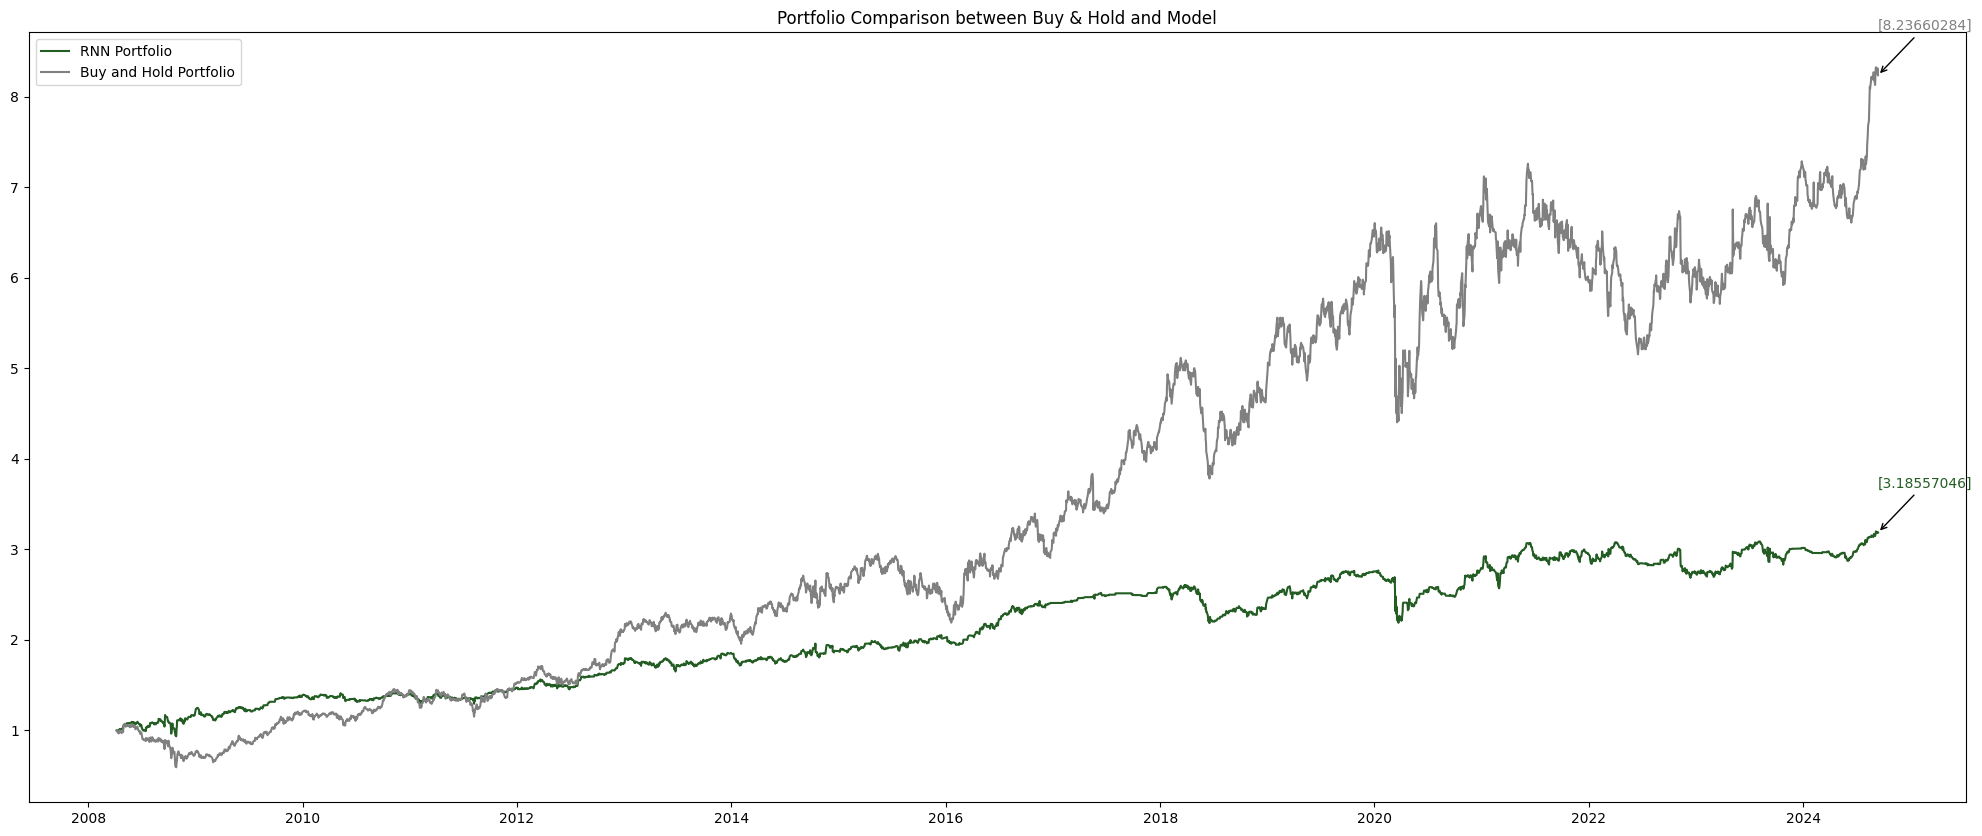

In [33]:
best_results_rnn_1, cuml_perf_rnn_1, max_sharpe_rnn_1, best_exp_idx_rnn = find_best_experiment(results_rnn_1, daily_returns)

plot_many_returns_series(
    [cuml_perf_rnn_1, buy_and_hold1],
    ["RNN Portfolio", "Buy and Hold Portfolio"], 
    daily_returns.index,
    colors=[model_colors["RNN"], model_colors["B&H"]]
)

# Random Forest

In [34]:
def define_rf(random_seed: int):
    rf = RandomForestClassifier(verbose=False, random_state=random_seed, n_jobs=-1)

    return rf

In [35]:
def run_rf_experiment(train_size: int, val_size: int, stock: str, random_seed: int):
    print(stock)
    np.random.seed(random_seed)
    random.seed(random_seed)
    tf.random.set_seed(random_seed)

    model = define_rf(random_seed)
    cv_splitter = SlidingWindowExclusiveTestCV(train_size, val_size)

    tests = []
    results = {}
    ground_y = []

    start_time = datetime.now()
    for train_index, test_index in cv_splitter.split(stocks_df):
        preprocessed_train_data = preprocess_data(stocks_df, stock, train_index[0], train_index[-1])
        preprocessed_test_data = preprocess_data(stocks_df, stock, test_index[0], test_index[-1])
        
        train_features = preprocessed_train_data.drop([f"{stock}_y"], axis=1)
        train_targets = preprocessed_train_data[f"{stock}_y"]

        test_features = preprocessed_test_data.drop([f"{stock}_y"], axis=1)
        test_targets = preprocessed_test_data[f"{stock}_y"]

        # just so I can rename variables
        X_train, X_test = train_features, test_features
        y_train, y_test = train_targets, test_targets

        model.fit(
            X_train, y_train
        )
        y_hat = model.predict(X_test)

        y_hat = np.array(y_hat)

        # append preds and grounds into array
        for i, y_pred in enumerate(y_hat):
            tests.append({y_test.index[i]: y_pred.astype(int)})
        
        for i, y_true in enumerate(y_hat):
            ground_y.append({y_test.index[i]: y_test.iloc[i].astype(int)})
            
    end_time = datetime.now()
    
    # extract values from result data structure
    preds_to_compute = [list(i.values())[0] for i in tests]
    grounds_to_compute = [list(i.values())[0] for i in ground_y]
    
    results = {
        "preds": preds_to_compute,
        "ground": grounds_to_compute,
        "accuracy": accuracy_score(grounds_to_compute, preds_to_compute),
        "f1": f1_score(grounds_to_compute, preds_to_compute),
        "precision": precision_score(grounds_to_compute, preds_to_compute, zero_division=0),
        "recall": recall_score(grounds_to_compute, preds_to_compute),
        "dataset_fit_predict_time": (end_time - start_time).total_seconds()
    }

    # all_accs.append(np.array(accs).mean())
    np.random.seed(RANDOM_STATE)
    random.seed(RANDOM_STATE)
    tf.random.set_seed(RANDOM_STATE)

    return results, tests

In [36]:
results_rf_1_path = "./results/rf_01"

if not os.path.isfile(results_rf_1_path):
    results_rf_1 = []

    for i in range(NUM_EXPERIMENTS):
        print(f"EXECUTION NUMBER {i+1}")
        abev3_rf_res, abev3_preds_rf = run_rf_experiment( 
            TRAIN_SIZE, 
            VAL_SIZE, 
            "abev3", 
            i
        )

        bbdc3_rf_res, bbdc3_preds_rf = run_rf_experiment(
            TRAIN_SIZE, 
            VAL_SIZE, 
            "bbdc3", 
            i
        )

        itsa3_rf_res, itsa3_preds_rf = run_rf_experiment(
            TRAIN_SIZE, 
            VAL_SIZE, 
            "itsa3", 
            i
        )

        itub3_rf_res, itub3_preds_rf = run_rf_experiment(
            TRAIN_SIZE, 
            VAL_SIZE, 
            "itub3", 
            i
        )

        wege3_rf_res, wege3_preds_rf = run_rf_experiment(
            TRAIN_SIZE, 
            VAL_SIZE, 
            "wege3", 
            i
        )

        results_rf_1.append({
            "abev3": (abev3_rf_res, abev3_preds_rf),
            "bbdc3": (bbdc3_rf_res, bbdc3_preds_rf),
            "itsa3": (itsa3_rf_res, itsa3_preds_rf),
            "itub3": (itub3_rf_res, itub3_preds_rf),
            "wege3": (wege3_rf_res, wege3_preds_rf)
        })

    !mkdir "./results/"
    with open(results_rf_1_path, "wb") as f:
        pickle.dump(results_rf_1, f)

else:
    with open(results_rf_1_path, "rb") as f:
        results_rf_1 = pickle.load(f)

Selected exp number 28


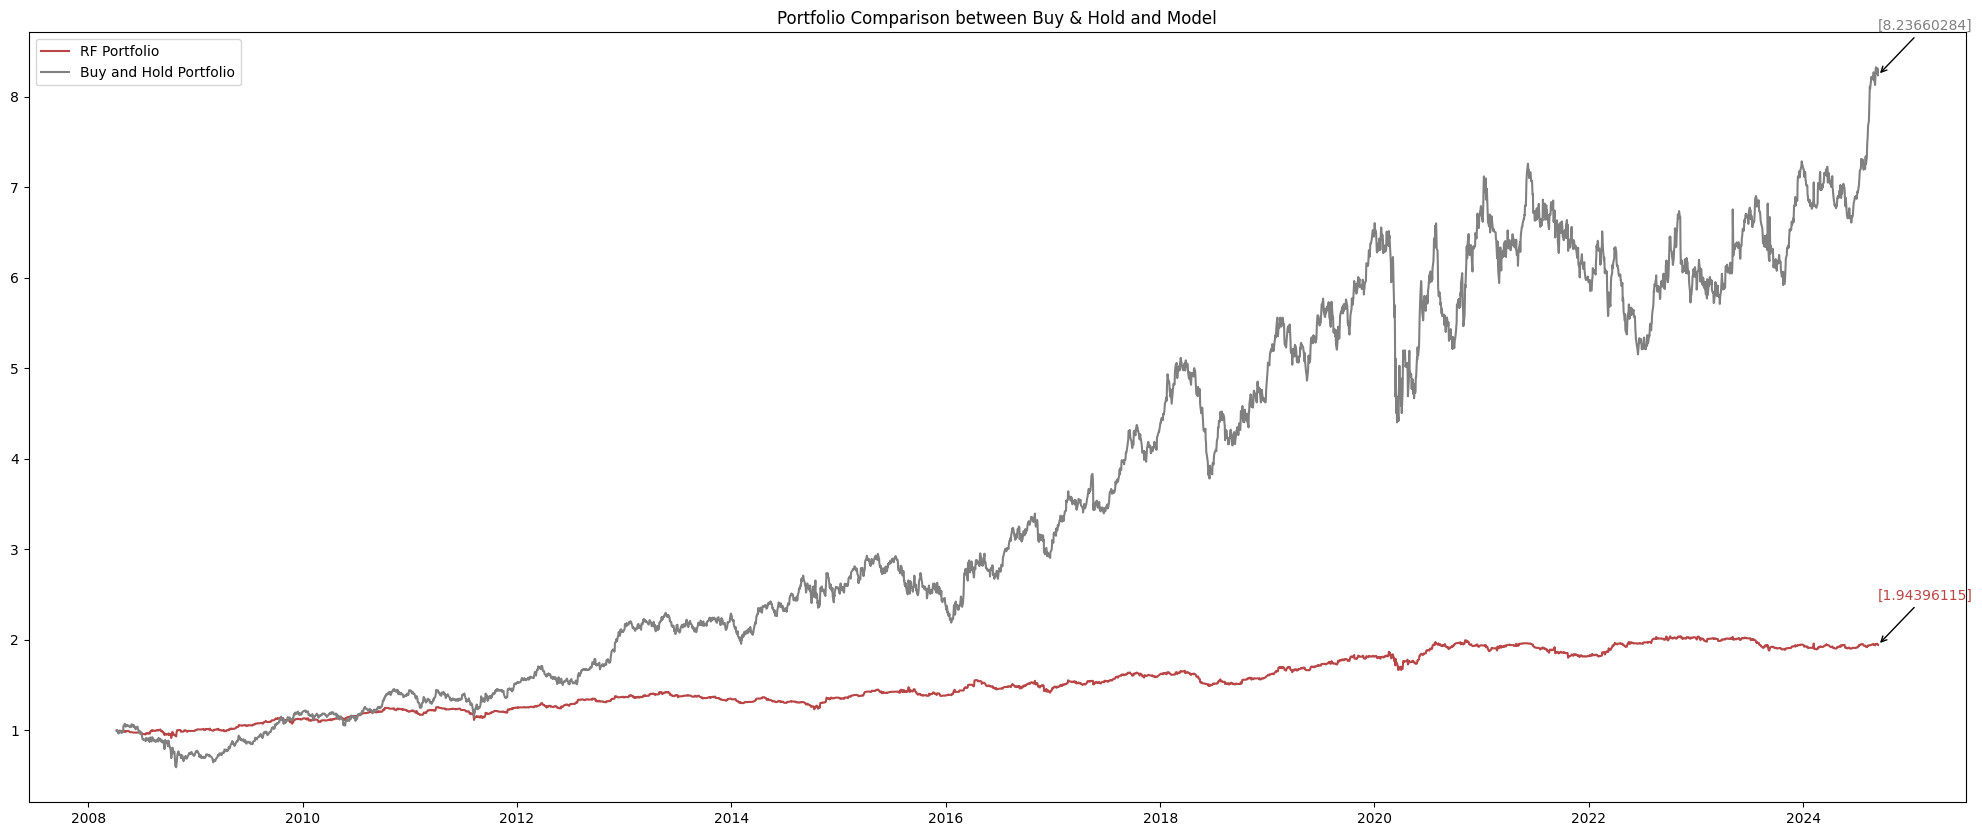

In [37]:
best_results_rf_1, cuml_perf_rf_1, max_sharpe_rf_1, best_exp_idx_rf = find_best_experiment(results_rf_1, daily_returns)

plot_many_returns_series(
    [cuml_perf_rf_1, buy_and_hold1],
    ["RF Portfolio", "Buy and Hold Portfolio"], 
    daily_returns.index,
    colors=[model_colors["RF"], model_colors["B&H"]]
)

# Random Guessing

In [38]:
def run_random_guessing_experiment(train_size: int, val_size: int, stock: str, random_seed: int):
    print(stock)
    np.random.seed(random_seed)
    random.seed(random_seed)
    tf.random.set_seed(random_seed)

    data = preprocess_data_test(stocks_df, stock)

    X = data.drop([f"{stock}_y"], axis=1)
    y_ground = data[f"{stock}_y"]

    cv_splitter = SlidingWindowExclusiveTestCV(train_size, val_size)

    tests = []
    results = {}
    ground_y = []

    for train_index, test_index in cv_splitter.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y_ground.iloc[train_index], y_ground.iloc[test_index]

        y_hat = np.random.choice([True, False], size=len(X_test))

        y_hat = np.array(y_hat)

        # append preds and grounds into array
        for i, y_pred in enumerate(y_hat):
            tests.append({y_test.index[i]: y_pred.astype(int)})
        
        for i, y_true in enumerate(y_hat):
            ground_y.append({y_test.index[i]: y_test.iloc[i].astype(int)})
            
    # extract values from result data structure

    preds_to_compute = [list(i.values())[0] for i in tests]
    grounds_to_compute = [list(i.values())[0] for i in ground_y]

    results = {
        "preds": preds_to_compute,
        "ground": grounds_to_compute,
        "accuracy": accuracy_score(grounds_to_compute, preds_to_compute),
        "f1": f1_score(grounds_to_compute, preds_to_compute),
        "precision": precision_score(grounds_to_compute, preds_to_compute, zero_division=0),
        "recall": recall_score(grounds_to_compute, preds_to_compute),
    }

    # all_accs.append(np.array(accs).mean())
    np.random.seed(RANDOM_STATE)
    random.seed(RANDOM_STATE)
    tf.random.set_seed(RANDOM_STATE)

    return results, tests

In [39]:
results_rg_1_path = "./results/rg_01"

if not os.path.isfile(results_rg_1_path):
    results_rg_1 = []

    for i in range(NUM_EXPERIMENTS):
        print(f"EXECUTION NUMBER {i+1}")
        abev3_rg_res, abev3_preds_rg = run_random_guessing_experiment( 
            TRAIN_SIZE, 
            VAL_SIZE, 
            "abev3", 
            i
        )

        bbdc3_rg_res, bbdc3_preds_rg = run_random_guessing_experiment(
            TRAIN_SIZE, 
            VAL_SIZE, 
            "bbdc3", 
            i
        )

        itsa3_rg_res, itsa3_preds_rg = run_random_guessing_experiment(
            TRAIN_SIZE, 
            VAL_SIZE, 
            "itsa3", 
            i
        )

        itub3_rg_res, itub3_preds_rg = run_random_guessing_experiment(
            TRAIN_SIZE, 
            VAL_SIZE, 
            "itub3", 
            i
        )

        wege3_rg_res, wege3_preds_rg = run_random_guessing_experiment(
            TRAIN_SIZE, 
            VAL_SIZE, 
            "wege3", 
            i
        )

        results_rg_1.append({
            "abev3": (abev3_rg_res, abev3_preds_rg),
            "bbdc3": (bbdc3_rg_res, bbdc3_preds_rg),
            "itsa3": (itsa3_rg_res, itsa3_preds_rg),
            "itub3": (itub3_rg_res, itub3_preds_rg),
            "wege3": (wege3_rg_res, wege3_preds_rg)
        })

    !mkdir "./results/"
    with open(results_rg_1_path, "wb") as f:
        pickle.dump(results_rg_1, f)

else:
    with open(results_rg_1_path, "rb") as f:
        results_rg_1 = pickle.load(f)

Selected exp number 26


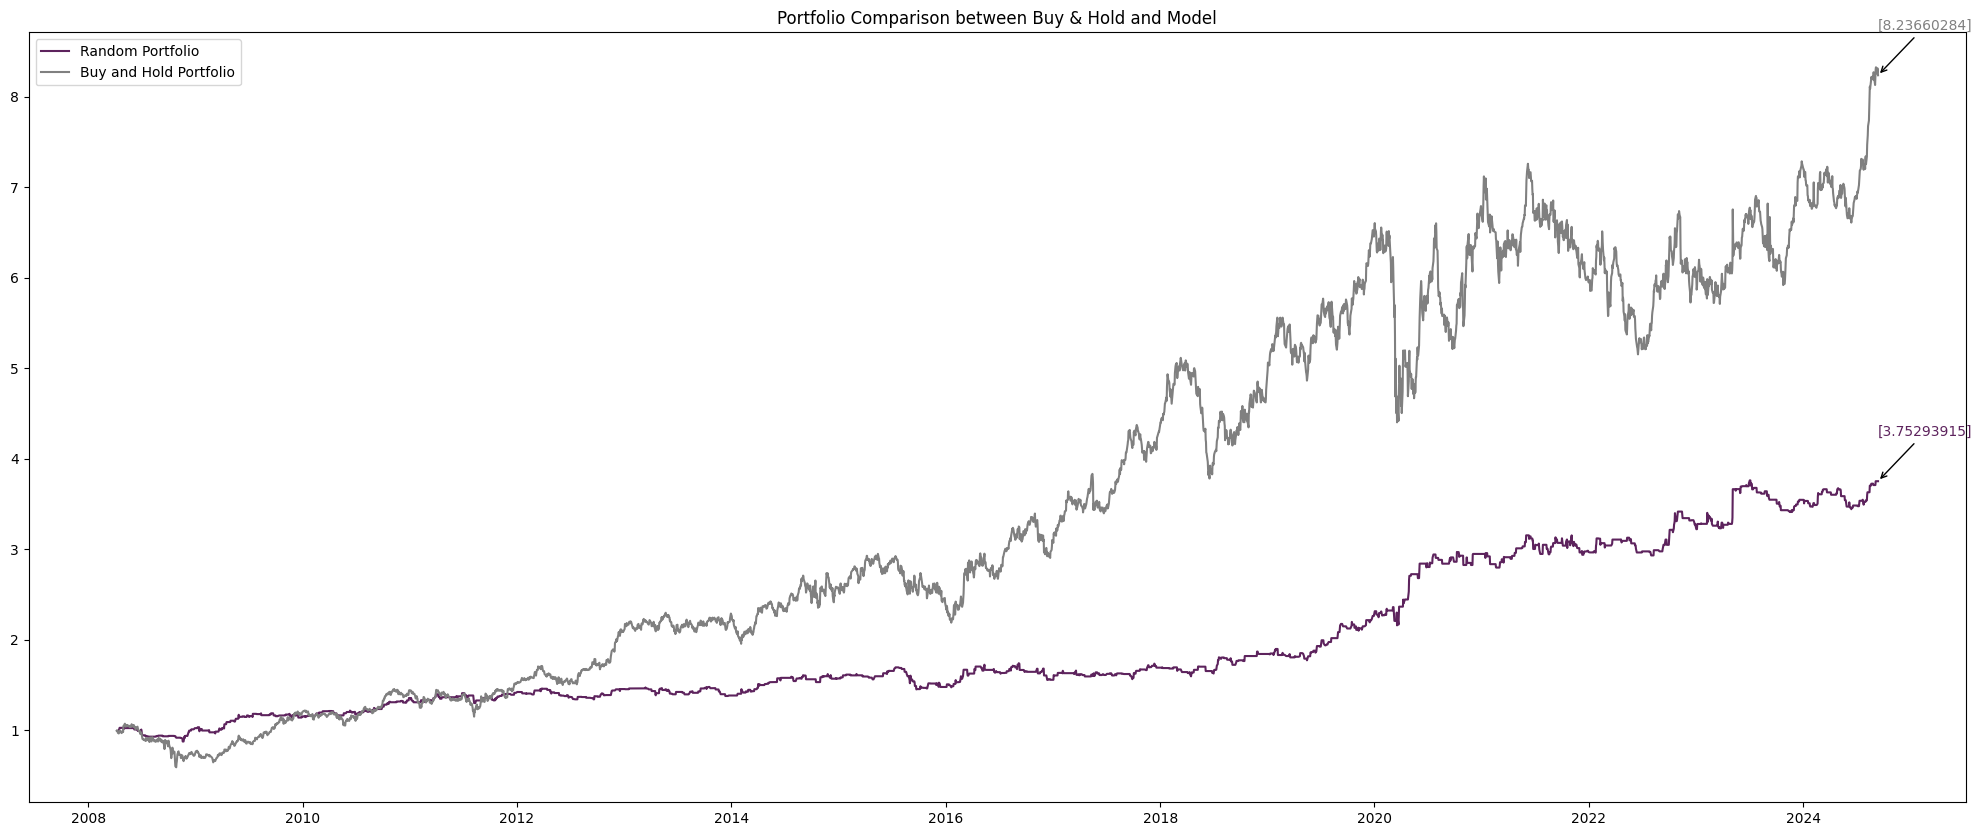

In [40]:
best_results_rg_1, cuml_perf_rg_1, max_sharpe_rg_1, best_exp_idx_rg = find_best_experiment(results_rg_1, daily_returns)

plot_many_returns_series(
    [cuml_perf_rg_1, buy_and_hold1],
    ["Random Portfolio", "Buy and Hold Portfolio"], 
    daily_returns.index,
    colors=[model_colors["RG"], model_colors["B&H"]]
)

Adianta-se que nenhum modelo conseguiu chegar nem a metade do que uma estratégia Buy and Hold atinge em termos de retornos acumulados. Mais detalhes no próximo notebook